Using haptools simgenotype, I am going to run a simple simulation of an admixture event between olives and yellows.
Origins chosen are Gog_Woreda and Mikumi, as they are the least admixed with a still good sample size.

Chr8 was run with the following options:
haptools simgenotype --model gog_mikumi_50gen.dat  --mapdir map_files/ --chroms 8 --ref_vcf ../chr8/chr8.phased.rehead.vcf.gz --sample_info aut.tsv --out chr8_gog_mik.vcf.gz

Model is
10  Admix  Gog_Woreda    Mikumi
1   0   0.8    0.2
50   1   0    0

Chromosome X was run with the following options:

haptools simgenotype --model gog_mikumi_50gen.dat  --mapdir map_files/ --chroms X --ref_vcf ../chrX_with_males/chrX_diploid_all_nomiss.vcf.gz --sample_info aut.tsv --out chrX_gog_mik.vcf.gz

With the same model, and a much older event with 

haptools simgenotype --model gog_mikumi_250gen.dat  --mapdir map_files/ --chroms X --ref_vcf ../chrX_with_males/chrX_diploid_all_nomiss.vcf.gz --sample_info aut.tsv --out chrX_gog_mik.vcf.gz

10  Admix  Gog_Woreda    Mikumi
1   0   0.8    0.2
250   1   0    0

In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format #

meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")

Rfmix results read

In [2]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/aut_sim_gog_mik/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_focus/" + \
                         "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': 0,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': 0}

df_l = []
for chrom in ["chr8"]: #["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr8


In [3]:
from ete3 import Tree

def plot_tree(t, ax, leaf_colors=None, show_inner_nodes=False, fontsize=10, 
              text_offset=None, margins=(0.5, 1, 0.5, 1)): # top, right, bottom, left

    y_offset = len(t.get_leaves())
    for node in t.traverse("preorder"):
        node.x_offset = node.dist + sum(x.dist for x in node.get_ancestors())
        if node.is_leaf():
            y_offset -= 1
            node.y_offset = y_offset

    for node in t.traverse("postorder"):
        if not node.is_leaf():
            node.y_offset = sum(x.y_offset for x in node.children) / len(node.children)

    horizontal_lines = list()
    vertical_lines = list()
    node_coords = list()
    leaf_coords = list()
    max_x_offset = 0
    for node in t.traverse("postorder"):
        max_x_offset = max(max_x_offset, node.x_offset)
        node_coords.append((node.x_offset, node.y_offset))
        if node.is_leaf():
            leaf_coords.append([node.name, node.x_offset, node.y_offset])
        if not node.is_root():
            y = node.y_offset
            horizontal_lines.append(([node.up.x_offset, node.x_offset], [y, y]))
        if not node.is_leaf():
            c = sorted(node.children, key=lambda x: x.y_offset)
            bottom, top = c[0], c[-1]
            x = node.x_offset
            vertical_lines.append(([x, x],[bottom.y_offset, top.y_offset]))

    
    # shift the tree to put leaves at zero
    for i in range(len(horizontal_lines)):
        horizontal_lines[i][0][0] -= max_x_offset
        horizontal_lines[i][0][1] -= max_x_offset
    for i in range(len(vertical_lines)):
        vertical_lines[i][0][0] -= max_x_offset
        vertical_lines[i][0][1] -= max_x_offset
    for i in range(len(leaf_coords)):
        leaf_coords[i][1] -= max_x_offset
            
    # draw the tree:
    for x in horizontal_lines:
        ax.plot(*x, c='black', linewidth=0.8)
    for x in vertical_lines:
        ax.plot(*x, c='black', linewidth=0.8)

#     for tup in node_coords:
#         ax.plot(*tup, c='black', marker="o")

    if text_offset is None:
        text_offset = max_x_offset / 20
        
    for name, x, y in leaf_coords:
        ax.text(x+text_offset, y, name, fontsize=fontsize,
                verticalalignment='center', horizontalalignment='left')
        if leaf_colors is None:
            color = 'black'
        else:
            color = leaf_colors[name]
        ax.plot(x, y, c=color, marker="o", ms=3)


#     ax.set_xlim(-margins[3], max_x_offset + margins[1])
    ax.set_xlim(-margins[3]-max_x_offset, margins[1])
    ax.set_ylim(-margins[2], len(leaf_coords)-1+margins[0])


    #ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax.spines['top'].set_visible(False) 
    ax.spines['left'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    
    return leaf_coords

def jc(seq1, seq2, case_sensitive=True):
    assert len(seq1) == len(seq2), (len(seq1), len(seq2))
    tot, diff = 0, 0
    for x, y in zip(seq1, seq2):
        if not case_sensitive:
            x, y = x.upper(), y.upper()
        if x in 'ATCG' and y in 'ATCG':
            if x != y:
                diff += 1
            tot += 1    
    if not tot:
        return np.nan
    elif diff:
        distance = -3/4 * math.log(1 - 4/3 * diff/tot)
    else:
        distance = 0.0
    return distance


def dist_matrix(seq_list, case_sensitive=True, dist_fun=jc):
    n = len(seq_list)
    mat = np.zeros((n, n))

    upper_trag_idx = list(zip(*np.triu_indices(n, k=1)))
#     seq_pairs = [(seq_list[i], seq_list[j]) for i, j in upper_trag_idx]
    args = [(seq_list[i], seq_list[j], case_sensitive) for i, j in upper_trag_idx]

    jc_distances = []
    for a, b, c in args:
        jc_distances.append(dist_fun(a, b, c))
    
    # with Pool(int(os.environ['SLURM_CPUS_PER_TASK'])) as p:
    #     jc_distances = p.starmap(dist_fun, args)

    for (i, j), d in zip(upper_trag_idx, jc_distances):
        mat[i][j] = d
        mat[j][i] = mat[i][j]

    return mat


def prune_nans(mat, name_list):

    # Find rows (and cols) where all off-diagonal entries are nan:
    mask = np.isnan(mat).sum(axis=0) == np.size(mat, axis=0)-1
    delete = [i for (i, delete) in enumerate(mask) if delete]
    # remove those rows and cols:
    mat = np.delete(mat, delete, axis=0)
    mat = np.delete(mat, delete, axis=1)
    # update name list:
    name_list = [name for (i, name) in enumerate(name_list) if i not in delete]
    
    # if there are any nans left we have to remove all row/cols with a nan:
    if np.isnan(mat).any():    
        # in that case we could do this to remove all row/cols with a nan
        mask = np.isnan(mat).sum(axis=0).astype('bool')
        delete = [i for (i, delete) in enumerate(mask) if delete]
        # remove those rows and cols:
        mat = np.delete(mat, delete, axis=0)
        mat = np.delete(mat, delete, axis=1)
        # update name list:
        name_list = [name for (i, name) in enumerate(name_list) if i not in delete]
        
    return mat, name_list

def find_lowest_cell(table):
    x = 1
    y = 0
    min_val = table[x][y]
    for i in range(len(table)):
        for j in range(len(table[i])):
            if table[i][j] < min_val:
                min_val = table[i][j]
                x = i
                y = j
    return [x, y]

def link(x, y, wx, wy):
    return (x * wx + y * wy) / (wx + wy)

def update_table(table, a, b, weight_a, weight_b):
    for i in range(0, b):
        table[b][i] = link(table[b][i], table[a][i], weight_b, weight_a)
    for j in range(b+1, a):
        table[j][b] = link(table[j][b], table[a][j], weight_b, weight_a)
    for i in range(a+1, len(table)):
        table[i][b] = link(table[i][b], table[i][a], weight_b, weight_a)
    for i in range(a+1, len(table)):
        del table[i][a]
    del table[a] 

def update_labels(labels, i, j, di, dj):
    labels[j] = "({}:{},{}:{})".format(labels[j], dj, labels[i], di)
    del labels[i]

def upgma(mat, names):

    table = mat[:]
    labels = names[:]
    node_heights = [0 for _ in labels]

    while len(labels) > 1:
        i, j = find_lowest_cell(table)
        
        dist = table[i][j]

        wi = max(1, labels[i].count(':'))
        wj = max(1, labels[j].count(':'))

        new_node_height = dist / 2
        di = new_node_height - node_heights[i]
        dj = new_node_height - node_heights[j]
        
        update_table(table, i, j, wi, wj)
        update_labels(labels, i, j, di, dj)
        node_heights[j] = new_node_height
        del node_heights[i]
        
    return labels[0] + ';'

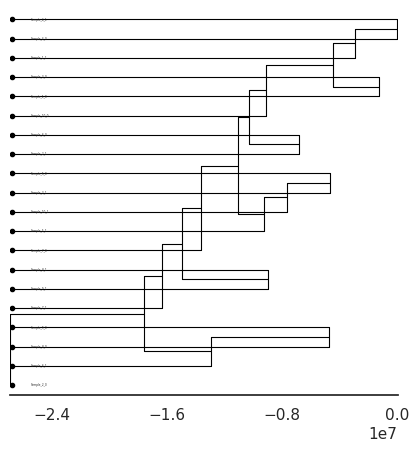

In [4]:
length_df["haplo_ID"] = length_df.individual +"_"+ length_df.haplotype
length_df["start"] = length_df.pos
length_df["north"] = length_df["n/s"]*2-1
length_df["total_north"] = length_df["north"]*length_df.length
length_df["is_north"] = [1 if x == 1 else 0 for x in length_df.north]
length_df["is_south"] = [0 if x == 1 else 1 for x in length_df.north]

haplo_ID_list = list(length_df.haplo_ID.unique())

north_south_segment_lists = []
for sample_name in haplo_ID_list:
    north_tuples = list(length_df.loc[(length_df.haplo_ID == sample_name) & (length_df.is_north == 1), ['pos', 'end_pos']].itertuples(index=False, name=None))
    south_tuples = list(length_df.loc[(length_df.haplo_ID == sample_name) & (length_df.is_north == 0), ['pos', 'end_pos']].itertuples(index=False, name=None))
    north_south_segment_lists.append((north_tuples, south_tuples))
    
def tree_newick(name_list, seq_list, case_sensitive=True, dist_fun=jc):

    mat = dist_matrix(seq_list, case_sensitive=case_sensitive, dist_fun=dist_fun)
    mat, name_list = prune_nans(mat, name_list)
    
    lowtri = [lst[:i] for (i, lst) in enumerate(mat.tolist())]
    newick_str = upgma(lowtri, name_list)
    return newick_str

def order_tree(t, key=lambda c: len(c.get_leaves())):
    """
    without key for sorting it makes a comb tree by default
    """
    for node in t.traverse():
        if not node.is_leaf():
            node.children = sorted(node.children, key=key, reverse=False)

def remove_outgroup(name):
    tree.set_outgroup( tree&name )
    all_leaves = tree.get_leaf_names()
    all_leaves.remove(name)
    tree.prune(all_leaves, preserve_branch_length=False)

def tot_overlap(arr1, arr2):
    """total overlap of two lists of intervals"""
    tot = 0
    i = j = 0
    n = len(arr1)
    m = len(arr2)
    while i < n and j < m:
        l = max(arr1[i][0], arr2[j][0])
        r = min(arr1[i][1], arr2[j][1])
        if l <= r: 
            tot += r - l
        if arr1[i][1] < arr2[j][1]:
            i += 1
        else:
            j += 1
    return tot

def proportion_same_ancestry(*args):
    """proportion of chromsome with same ancestry"""
    a, b, case_sensitive = args
    ovl = tot_overlap(a[0], b[0]) + tot_overlap(a[1], b[1])
    return 77000000 - ovl
    
newick_str = tree_newick(haplo_ID_list, north_south_segment_lists, dist_fun=proportion_same_ancestry)
tree = Tree(newick_str)

def order_fun(c):
    """order child clades so that leaves in left has more north ancestry"""
    leaf_names = [x.name for x in c.get_leaves()]
    idx = [haplo_ID_list.index(x) for x in leaf_names]
    return sum(e-s for i in idx for (s, e) in north_south_segment_lists[i][1]) - sum(e-s for i in idx for (s, e) in north_south_segment_lists[i][0])

order_tree(tree, key=order_fun)

fig, ax1 = plt.subplots(1, 1, sharey=True, figsize=(5, 5))

leaf_info = plot_tree(tree, ax1, fontsize=2)
haplo_ID_sorting, x, y = zip(*leaf_info)

In [5]:
length_df.loc[length_df.north == 1].length.sum()/length_df.length.sum()

0.8259854042154013

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


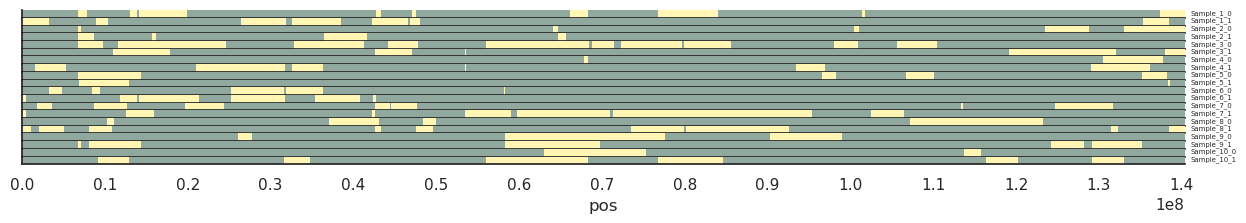

In [6]:
def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

g = sns.FacetGrid(stairs(length_df).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(length_df).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = length_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(plot_df.pos)+1, 10000000))

Checking the breakpoints file

In [7]:
pos_l, end_pos_l, haplo_ID_l, orig_l = [], [], [], []
f = open("/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/sim_haptools/chr8_gog_mik.bp")

for l in f.readlines():
    if l[:6] == "Sample":
        haplo_ID = l.strip()
        prev_pos = 0
    else:
        split_bp = l.strip().split("\t")
        pos_l.append(int(prev_pos))
        end_pos_l.append(int(split_bp[2]))
        prev_pos = split_bp[2]
        orig_l.append(split_bp[0])
        haplo_ID_l.append(haplo_ID)

In [8]:
bp_df = pd.DataFrame({"pos": pos_l, "end_pos": end_pos_l, "haplo_ID": haplo_ID_l, "origin": orig_l})
bp_df["is_north"] = [1 if x == "Gog_Woreda" else 0 for x in bp_df.origin]
bp_df["is_south"] = [0 if x == "Gog_Woreda" else 1 for x in bp_df.origin]
bp_df["chrom"] = "chr8"

In [9]:
bp_df

,pos,end_pos,haplo_ID,origin,is_north,is_south,chrom
0,0,144376,Sample_1_1,Gog_Woreda,1,0,chr8
1,144376,1654293,Sample_1_1,Gog_Woreda,1,0,chr8
2,1654293,3445960,Sample_1_1,Gog_Woreda,1,0,chr8
3,3445960,3662719,Sample_1_1,Gog_Woreda,1,0,chr8
4,3662719,3748733,Sample_1_1,Gog_Woreda,1,0,chr8
...,...,...,...,...,...,...,...
1196,137898446,138419354,Sample_10_2,Mikumi,0,1,chr8
1197,138419354,139222818,Sample_10_2,Gog_Woreda,1,0,chr8
1198,139222818,139659248,Sample_10_2,Gog_Woreda,1,0,chr8
1199,139659248,140166837,Sample_10_2,Gog_Woreda,1,0,chr8


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


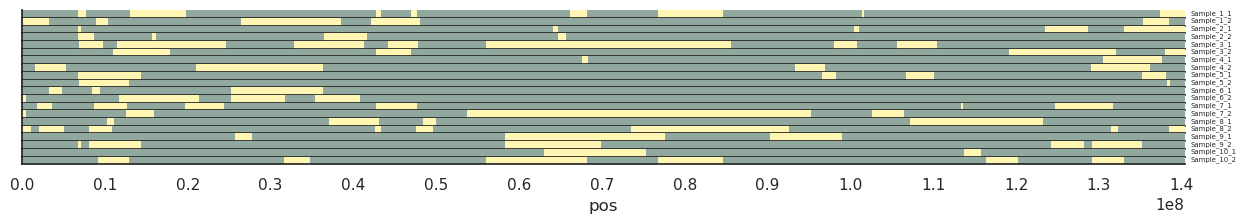

In [10]:
def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

g = sns.FacetGrid(stairs(bp_df).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(bp_df).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = bp_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(bp_df.pos)+1, 10000000))

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


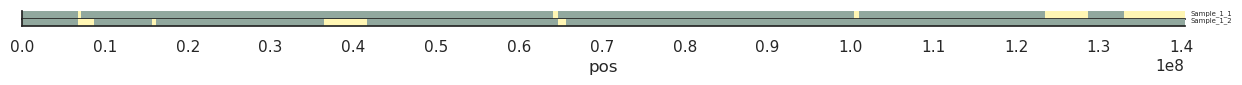

In [11]:
input_df = bp_df.loc[bp_df.haplo_ID.isin(["Sample_1_1", "Sample_1_2"])]

g = sns.FacetGrid(stairs(input_df).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(input_df).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = input_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(plot_df.pos)+1, 10000000))

Counting how much is correctly identified.

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


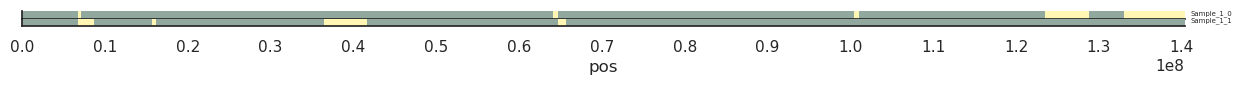

In [12]:
input_df = length_df.loc[length_df.haplo_ID.isin(["Sample_1_0", "Sample_1_1"])]

g = sns.FacetGrid(stairs(input_df), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(input_df)
haplo_ID_sorting = input_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(plot_df.pos)+1, 10000000))

In [13]:
length_df

,pos,end_pos,length,reference,n/s,individual,haplotype,chrom,haplo_ID,start,north,total_north,is_north,is_south
0,4263,744233,739971,"Hamadryas, Ethiopia",1,Sample_1,0,chr8,Sample_1_0,4263,1,739971,1,0
1,744234,1362155,617922,"Papio, Senegal",1,Sample_1,0,chr8,Sample_1_0,744234,1,617922,1,0
2,1362156,4840882,3478727,"Hamadryas, Ethiopia",1,Sample_1,0,chr8,Sample_1_0,1362156,1,3478727,1,0
3,4840883,5342572,501690,"Papio, Senegal",1,Sample_1,0,chr8,Sample_1_0,4840883,1,501690,1,0
4,5342573,6586363,1243791,"Hamadryas, Ethiopia",1,Sample_1,0,chr8,Sample_1_0,5342573,1,1243791,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,129670332,135309498,5639167,"Hamadryas, Ethiopia",1,Sample_10,1,chr8,Sample_10_1,129670332,1,5639167,1,0
42,135309499,138417816,3108318,"Kindae, Zambia",0,Sample_10,1,chr8,Sample_10_1,135309499,-1,-3108318,0,1
43,138417817,138735453,317637,"Hamadryas, Ethiopia",1,Sample_10,1,chr8,Sample_10_1,138417817,1,317637,1,0
44,138735454,139470411,734958,"Papio, Senegal",1,Sample_10,1,chr8,Sample_10_1,138735454,1,734958,1,0


In [14]:
bp_df

,pos,end_pos,haplo_ID,origin,is_north,is_south,chrom
0,0,144376,Sample_1_1,Gog_Woreda,1,0,chr8
1,144376,1654293,Sample_1_1,Gog_Woreda,1,0,chr8
2,1654293,3445960,Sample_1_1,Gog_Woreda,1,0,chr8
3,3445960,3662719,Sample_1_1,Gog_Woreda,1,0,chr8
4,3662719,3748733,Sample_1_1,Gog_Woreda,1,0,chr8
...,...,...,...,...,...,...,...
1196,137898446,138419354,Sample_10_2,Mikumi,0,1,chr8
1197,138419354,139222818,Sample_10_2,Gog_Woreda,1,0,chr8
1198,139222818,139659248,Sample_10_2,Gog_Woreda,1,0,chr8
1199,139659248,140166837,Sample_10_2,Gog_Woreda,1,0,chr8


In [15]:
import pandas as pd
import numpy as np
from chromwindow import window

@window(size=100000)
def north_sum(df):
    r = (df.end-df.start).sum()
    return r

def add_dummy(c_df):
    inds = c_df.individual.unique()
    dummy_df = pd.DataFrame({"individual": np.repeat(inds, 2)})
    dummy_df["haplotype"] = pd.Series(["0", "1"]*len(inds))
    dummy_df["end"], dummy_df["start"] = c_df.end.max(), c_df.end.max()
    dummy_df["chrom"] = c_df.chrom.unique()[0]
    return dummy_df

c_df = length_df.loc[(length_df["n/s"] == 1)]
c_df = c_df.rename(columns={"end_pos": "end"})
dummy_added = pd.concat([c_df[["individual", "haplotype", "end", "start", "chrom"]], add_dummy(c_df)])
window_df = dummy_added.groupby(['individual', 'haplotype']).apply(north_sum).reset_index(drop=True, level=-1).reset_index()

In [16]:
def add_dummy(c_df):
    inds = c_df.individual.unique()
    dummy_df = pd.DataFrame({"individual": np.repeat(inds, 2)})
    dummy_df["haplotype"] = pd.Series(["1", "2"]*len(inds))
    dummy_df["end"], dummy_df["start"] = c_df.end.max(), c_df.end.max()
    dummy_df["chrom"] = c_df.chrom.unique()[0]
    return dummy_df

b_df = bp_df.loc[(bp_df["is_north"] == 1)]
b_df = b_df.rename(columns={"end_pos": "end", "pos": "start"})
b_df["individual"] = b_df.haplo_ID.str[:-2]
b_df["haplotype"] = b_df.haplo_ID.str[-1:]
dummy_added = pd.concat([b_df[["individual", "haplotype", "end", "start", "chrom"]], add_dummy(b_df)])
bp_df_window = dummy_added.groupby(['individual', 'haplotype']).apply(north_sum).reset_index(drop=True, level=-1).reset_index()

In [17]:
mean_df = window_df.groupby(["individual", "start", "end"]).mean().reset_index()
mean_bp_df = bp_df_window.groupby(["individual", "start", "end"]).mean().reset_index()

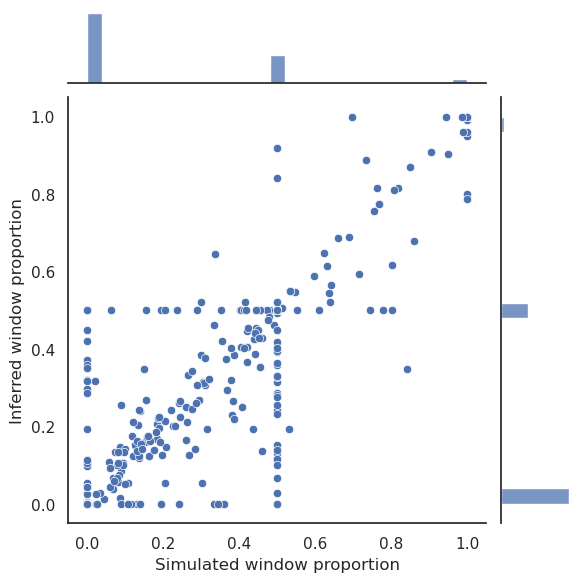

In [18]:
g = sns.jointplot(y=(100000-mean_df.north_sum)/100000, x=(100000-mean_bp_df.north_sum)/100000)
g.set_axis_labels("Simulated window proportion", "Inferred window proportion")

In [19]:
from scipy import stats
stats.spearmanr(mean_df.north_sum, mean_bp_df.north_sum)

SignificanceResult(statistic=0.9641443674941644, pvalue=0.0)

In [20]:
stats.pearsonr(mean_df.north_sum, mean_bp_df.north_sum)

PearsonRResult(statistic=0.9893258827176503, pvalue=0.0)

In [21]:
mean_df["w_l"] = window_df.end-window_df.start
1-mean_df.north_sum.sum()/mean_df.w_l.sum()

0.17436390918803424

In [22]:
mean_bp_df["w_l"] = mean_bp_df.end-mean_bp_df.start
1-mean_bp_df.north_sum.sum()/mean_bp_df.w_l.sum()

0.175816004985755

In [23]:
stats.ttest_ind(mean_df.north_sum, mean_bp_df.north_sum)

Ttest_indResult(statistic=0.44672455530590127, pvalue=0.655077395425556)

Chromosome X sims. Determining which is the best 

In [24]:
pos_l, end_pos_l, haplo_ID_l, orig_l = [], [], [], []
f = open("/home/eriks/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021/sim_haptools/X_250gog_mikumi_250gen.bp")

for l in f.readlines():
    if l[:6] == "Sample":
        haplo_ID = l.strip()
        prev_pos = 0
    else:
        split_bp = l.strip().split("\t")
        pos_l.append(int(prev_pos))
        end_pos_l.append(int(split_bp[2]))
        prev_pos = split_bp[2]
        orig_l.append(split_bp[0])
        haplo_ID_l.append(haplo_ID)

In [60]:
bp_df = pd.DataFrame({"pos": pos_l, "end_pos": end_pos_l, "haplo_ID": haplo_ID_l, "origin": orig_l})
bp_df["length"] = bp_df.end_pos-bp_df.pos
bp_df["is_north"] = [1 if x == "Gog_Woreda" else 0 for x in bp_df.origin]
bp_df["is_south"] = [0 if x == "Gog_Woreda" else 1 for x in bp_df.origin]
bp_df["chrom"] = "chrX"

In [61]:
bp_df.loc[bp_df["is_north"] == 1]["length"].sum()

2261064783

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


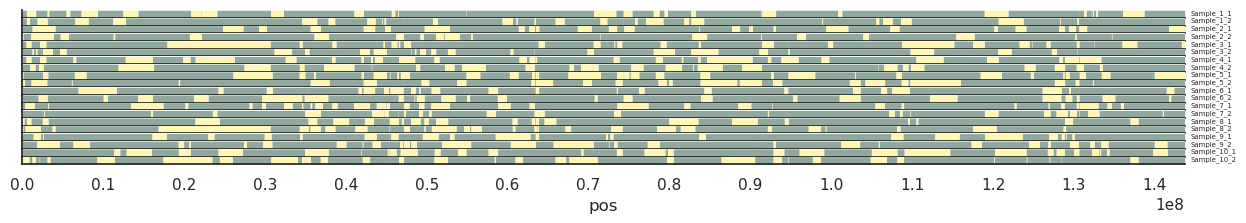

In [26]:
def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

g = sns.FacetGrid(stairs(bp_df).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(bp_df).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = bp_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(bp_df.pos)+1, 10000000))

In [133]:
import glob
gen250_runs = glob.glob("../steps/rfmix_gen100/sim_results/gen250*infer*msp.tsv")+glob.glob("../steps/rfmix_gen100/sim_results_plain/gen250*infer*msp.tsv")
gen250_runs

['../steps/rfmix_gen100/sim_results/gen250_infer1000_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_infer100_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_female_infer250_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_female_infer500_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_infer50_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_female_infer50_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_female_infer1000_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_infer250_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_infer500_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results/gen250_female_infer100_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results_plain/gen250_female_infer50_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results_plain/gen250_infer500_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results_plain/gen250_infer250_chrX.msp.tsv',
 '../steps/rfmix_gen100/sim_results_plain/gen250_infer1000_chrX.msp.ts

In [134]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/aut_sim_gog_mik/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_focus/" + \
                         "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o

north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': 0,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': 0}

df_l = []
for p in gen250_runs:
    print(p)
    file_name = p.split("/")[-1]
    chr_df = pd.read_csv(p, sep = "\t", header=1)
    file = open(p, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    df_paint_l = []
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        df_paint_l.append(paint_df)
    paint_df_all = pd.concat(df_paint_l)
    c_df = paint_df_all.loc[(paint_df_all["n/s"] == 1)]
    c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
    c_df["chrom"] = "chrX"
    dummy_added = pd.concat([c_df[["individual", "haplotype", "end", "start", "chrom"]], add_dummy(c_df)])
    window_df = dummy_added.groupby(['individual', 'haplotype']).apply(north_sum).reset_index(drop=True, level=-1).reset_index()
    window_df["gen_infer"] = file_name.split("infer")[-1].split("_chrX")[0]
    if "female" in p:
        window_df["female_only"] = True
    else:
        window_df["female_only"] = False
    if "plain" in p:
        window_df["reanalyze"] = False
    else:
        window_df["reanalyze"] = True
    df_l.append(window_df)
window_df_gen250 = pd.concat(df_l)

../steps/rfmix_gen100/sim_results/gen250_infer1000_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_infer100_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_female_infer250_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_female_infer500_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_infer50_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_female_infer50_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_female_infer1000_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_infer250_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_infer500_chrX.msp.tsv
../steps/rfmix_gen100/sim_results/gen250_female_infer100_chrX.msp.tsv
../steps/rfmix_gen100/sim_results_plain/gen250_female_infer50_chrX.msp.tsv
../steps/rfmix_gen100/sim_results_plain/gen250_infer500_chrX.msp.tsv
../steps/rfmix_gen100/sim_results_plain/gen250_infer250_chrX.msp.tsv
../steps/rfmix_gen100/sim_results_plain/gen250_infer1000_chrX.msp.tsv
../steps/rfmix_gen100/sim_results_plain/gen250_femal

In [135]:
b_df = bp_df.loc[(bp_df["is_north"] == 1)]
b_df = b_df.rename(columns={"end_pos": "end", "pos": "start"})
b_df["individual"] = b_df.haplo_ID.str[:-2]
b_df["haplotype"] = b_df.haplo_ID.str[-1:]
dummy_added = pd.concat([b_df[["individual", "haplotype", "end", "start", "chrom"]], add_dummy(b_df)])
bp_df_window = dummy_added.groupby(['individual', 'haplotype']).apply(north_sum).reset_index(drop=True, level=-1).reset_index()

In [148]:
2500000
window_df_gen250

,individual,haplotype,start,end,north_sum,gen_infer,female_only,reanalyze
0,Sample_1,0,0,100000,0,1000,False,True
1,Sample_1,0,100000,200000,0,1000,False,True
2,Sample_1,0,200000,300000,0,1000,False,True
3,Sample_1,0,300000,400000,0,1000,False,True
4,Sample_1,0,400000,500000,0,1000,False,True
...,...,...,...,...,...,...,...,...
43042,Sample_9,2,143200000,143300000,0,100,True,False
43043,Sample_9,2,143300000,143400000,0,100,True,False
43044,Sample_9,2,143400000,143500000,0,100,True,False
43045,Sample_9,2,143500000,143600000,0,100,True,False


In [150]:
mean_bp_df = bp_df_window.groupby(["individual", "start", "end"]).mean().reset_index()
mean_bp_df_s = mean_bp_df.loc[mean_bp_df.start >= 2500000]
g_l, f_l, r_l, pearson_l = [], [], [], []
for g in ["50", "100", "250", "500", "1000"]:
    for f in [False, True]:
        for r in [False, True]:
            print(g, f, r)
            sub_df = window_df_gen250.loc[(window_df_gen250.gen_infer == g)
                                 & (window_df_gen250.female_only == f)
                                 & (window_df_gen250.reanalyze == r) 
                                 & (window_df_gen250.start >= 2500000)]
            mean_df = sub_df.groupby(["individual", "start", "end"]).mean().reset_index()
            res, pval = stats.pearsonr(mean_df.north_sum, mean_bp_df_s.north_sum)
            print(stats.pearsonr(mean_df.north_sum, mean_bp_df_s.north_sum))
            g_l.append(g), f_l.append(f), r_l.append(r)
            pearson_l.append(res)

50 False False
PearsonRResult(statistic=0.9669292913595384, pvalue=0.0)
50 False True
PearsonRResult(statistic=0.9664300228820482, pvalue=0.0)
50 True False
PearsonRResult(statistic=0.9509114531946264, pvalue=0.0)
50 True True
PearsonRResult(statistic=0.950743398074053, pvalue=0.0)
100 False False
PearsonRResult(statistic=0.9673090574646497, pvalue=0.0)
100 False True
PearsonRResult(statistic=0.9671545865757216, pvalue=0.0)
100 True False
PearsonRResult(statistic=0.965418833755687, pvalue=0.0)
100 True True
PearsonRResult(statistic=0.9653264430574201, pvalue=0.0)
250 False False
PearsonRResult(statistic=0.9591126028715151, pvalue=0.0)
250 False True
PearsonRResult(statistic=0.9579702427456295, pvalue=0.0)
250 True False
PearsonRResult(statistic=0.9639304919481262, pvalue=0.0)
250 True True
PearsonRResult(statistic=0.9639216146078123, pvalue=0.0)
500 False False
PearsonRResult(statistic=0.9530470779078111, pvalue=0.0)
500 False True
PearsonRResult(statistic=0.9531220252549003, pvalue=0.

In [151]:
pd.DataFrame({"Generations": g_l, "Female refs only": f_l, "Reanalyze reference": r_l, "Pearsons R": pearson_l})

,Generations,Female refs only,Reanalyze reference,Pearsons R
0,50,False,False,0.967
1,50,False,True,0.966
2,50,True,False,0.951
3,50,True,True,0.951
4,100,False,False,0.967
5,100,False,True,0.967
6,100,True,False,0.965
7,100,True,True,0.965
8,250,False,False,0.959
9,250,False,True,0.958


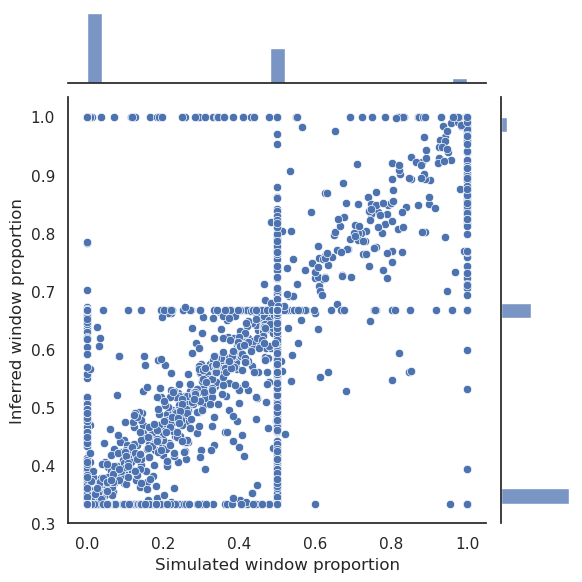

In [127]:
g = sns.jointplot(y=(100000-mean_df.north_sum)/100000, x=(100000-mean_bp_df.north_sum)/100000)
g.set_axis_labels("Simulated window proportion", "Inferred window proportion")

In [140]:
for p in ["../steps/rfmix_gen100/sim_results/gen250_infer100_chrX.msp.tsv"]:
    print(p)
    file_name = p.split("/")[-1]
    chr_df = pd.read_csv(p, sep = "\t", header=1)
    file = open(p, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    df_paint_l = []
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        df_paint_l.append(paint_df)
    paint_df_all = pd.concat(df_paint_l)

../steps/rfmix_gen100/sim_results/gen250_infer100_chrX.msp.tsv


In [144]:
paint_df_all

,pos,end_pos,length,reference,n/s,individual,haplotype,haplo_ID,start,north,total_north,is_north,is_south,chrom
0,2500194,3742867,1242674,"Kindae, Zambia",0,Sample_1,0,Sample_1_0,2500194,-1,-1242674,0,1,chrX
1,3742868,4071875,329008,"Ursinus, Zambia",0,Sample_1,0,Sample_1_0,3742868,-1,-329008,0,1,chrX
2,4071876,5129453,1057578,"Papio, Senegal",1,Sample_1,0,Sample_1_0,4071876,1,1057578,1,0,chrX
3,5129454,5277422,147969,"Hamadryas, Ethiopia",1,Sample_1,0,Sample_1_0,5129454,1,147969,1,0,chrX
4,5277423,6064235,786813,"Papio, Senegal",1,Sample_1,0,Sample_1_0,5277423,1,786813,1,0,chrX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,131391154,132336674,945521,"Papio, Senegal",1,Sample_10,1,Sample_10_1,131391154,1,945521,1,0,chrX
198,132336675,133497733,1161059,"Hamadryas, Ethiopia",1,Sample_10,1,Sample_10_1,132336675,1,1161059,1,0,chrX
199,133497734,133730731,232998,"Papio, Senegal",1,Sample_10,1,Sample_10_1,133497734,1,232998,1,0,chrX
200,133730732,137942170,4211439,"Hamadryas, Ethiopia",1,Sample_10,1,Sample_10_1,133730732,1,4211439,1,0,chrX


/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


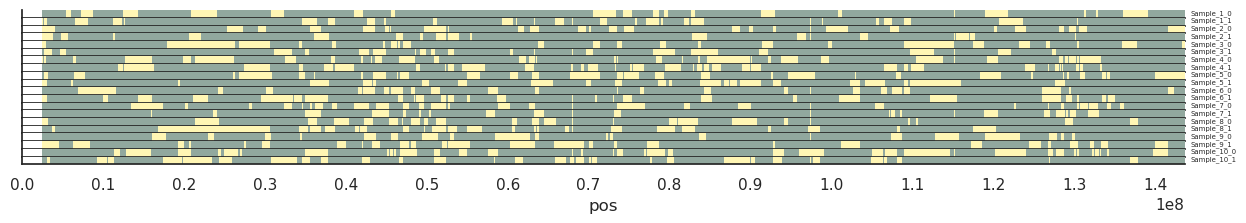

In [143]:
paint_df_all["haplo_ID"] = paint_df_all.individual +"_"+ paint_df_all.haplotype
paint_df_all["start"] = paint_df_all.pos
paint_df_all["north"] = paint_df_all["n/s"]*2-1
paint_df_all["total_north"] = paint_df_all["north"]*paint_df_all.length
paint_df_all["is_north"] = [1 if x == 1 else 0 for x in paint_df_all.north]
paint_df_all["is_south"] = [0 if x == 1 else 1 for x in paint_df_all.north]
paint_df_all["chrom"] = "chrX"

g = sns.FacetGrid(stairs(paint_df_all).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(paint_df_all).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = paint_df_all.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(bp_df.pos)+1, 10000000))